# Per-cell PID control of an optogenetic gene circuit

Demonstrates the **time-varying input** feature of `crn_jax`. Each replicate (cell) gets its own PID controller and its own setpoint trajectory — the controllers compute light intensity `u(t) ∈ [0, 1]` per cell per control interval, and the simulator advances each cell independently with its own input. The whole closed loop is `vmap`'d over cells and `lax.scan`'d over time, so thousands of independently-controlled cells run as a single JIT-compiled call.

**Plant**: `cca_optogenetic` — the CcaS/CcaR light-driven gene-expression circuit (Olson et al. 2014, Tabor lab). Green light activates the CcaR transcription factor `R`, which drives reporter expression `P`. Input `u ∈ [0, 1]` is the green-light fraction. The deterministic transfer is sigmoidal: `⟨P⟩_ss(u)` ranges from ~2 (full red) to ~110 (full green).

**Controller**: standard PID on `P` (the observable output), output clipped to `[0, 1]`. Each cell has its own gains (we use the same gains here, but they could be per-cell too).

**Setpoints**: 5 cells, 5 distinct setpoint trajectories — constant, step, sine, ramp, square. The point is that each cell follows its own target while sharing the same plant model and controller architecture.

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from crn_jax import models
from crn_jax.gillespie import simulate_interval
from crn_jax.types import State

## 1. The plant: `cca_optogenetic`

Two-species input-driven model — `R` (active CcaR) ramps up at rate `k_R · u`, drives `P` through a Hill activator. Let's first verify the deterministic steady-state transfer curve so we know what range of `P` the controller can actually reach.

Plant params: {'k_R': 4.62, 'gamma_R': 0.0462, 'beta_P0': 0.167, 'beta_P1': 5.0, 'K': 50.0, 'n': 2.0, 'gamma_P': 0.0231}


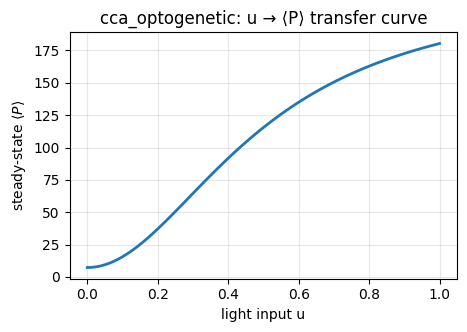

P range: 7.2 (u=0) → 180.4 (u=1)


In [3]:
params = models.cca_optogenetic.Params.default()
print("Plant params:", params.__dict__)


def Pss(u):
    """Deterministic steady-state P as a function of light input u."""
    R = params.k_R * u / params.gamma_R
    hill = R**params.n / (params.K**params.n + R**params.n)
    return (params.beta_P0 + params.beta_P1 * hill) / params.gamma_P


u_grid = np.linspace(0, 1, 101)
P_grid = np.array([Pss(u) for u in u_grid])
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(u_grid, P_grid, lw=2)
ax.set_xlabel("light input u")
ax.set_ylabel(r"steady-state $\langle P \rangle$")
ax.set_title("cca_optogenetic: u → ⟨P⟩ transfer curve")
ax.grid(alpha=0.3)
plt.show()
print(f"P range: {P_grid[0]:.1f} (u=0) → {P_grid[-1]:.1f} (u=1)")

## 2. Per-cell setpoints

Five cells, each with a different target trajectory:

- **Cell 0**: constant `P = 60`
- **Cell 1**: step from 30 → 80 at t = 500 min
- **Cell 2**: sine wave around 50, amplitude 30, period 400 min
- **Cell 3**: linear ramp from 20 to 90 over the full simulation
- **Cell 4**: square wave alternating between 30 and 80 every 200 min

These cover constant tracking, step response, periodic tracking, ramping, and disturbance rejection.

In [8]:
N_CELLS = 5
DT = 5.0  # control interval (min) — re-evaluate PID + run simulator for DT each step
N_INTERVALS = 200  # total simulated time = DT · N_INTERVALS = 1000 min
T_TOTAL = DT * N_INTERVALS


def setpoints_at(t):
    """Per-cell setpoint at time t. Returns (N_CELLS,) array.

    All setpoints chosen to lie within the plant's reachable P range
    [Pmin≈7, Pmax≈180] — Schmidl 2014's 25× fold change.
    """
    s0 = 90.0  # constant mid-range
    s1 = jnp.where(t < 500.0, 20.0, 150.0)  # step
    s2 = 90.0 + 70.0 * jnp.sin(2 * jnp.pi * t / 400.0)  # sine, range 20–160
    s3 = 15.0 + (170.0 - 15.0) * (t / T_TOTAL)  # linear ramp
    s4 = jnp.where((jnp.floor(t / 200.0) % 2) == 0, 25.0, 160.0)  # square wave
    return jnp.array([s0, s1, s2, s3, s4])


times = jnp.arange(N_INTERVALS) * DT
setpoint_traj = jax.vmap(setpoints_at)(times)  # (N_INTERVALS, N_CELLS)
print("Setpoint trajectory shape:", setpoint_traj.shape)

Setpoint trajectory shape: (200, 5)


## 3. Closed-loop PID controller

The control loop runs at intervals of `DT = 5 min` (re-evaluating `u` every 5 min and advancing the SSA simulator for that long). Standard discretised PID:

$$u_k = \mathrm{clip}\big(K_p\, e_k + K_i \sum_{j \le k} e_j \Delta t + K_d (e_k - e_{k-1})/\Delta t,\ 0,\ 1\big)$$

where $e_k = \mathrm{setpoint}_k - P_k$.

Implementation: one `control_step` function takes per-cell state + PID memory + setpoint, computes `u`, and advances the simulator by `DT` with that `u`. `vmap` makes it run per-cell; `lax.scan` iterates over time intervals. Everything is JIT-compiled into a single XLA call.

In [5]:
# PID gains (hand-tuned for this plant — see exercise below).
KP = 0.020
KI = 0.0008
KD = 0.0

MODEL = models.cca_optogenetic
PROP_FN = MODEL.propensities_fn(params)
APPLY_FN = MODEL.apply_reaction
P_IDX = 1  # observable is P, the second species
MAX_RXNS_PER_INTERVAL = 10_000


def control_step_one_cell(state, integral, prev_err, key, setpoint, dt):
    """One PID + simulator step for one cell."""
    P_now = state.x[P_IDX]
    err = setpoint - P_now
    integral_new = integral + err * dt
    deriv = (err - prev_err) / dt
    u = jnp.clip(KP * err + KI * integral_new + KD * deriv, 0.0, 1.0)

    new_state = simulate_interval(
        key=key,
        state=state,
        input=u,
        timestep=dt,
        max_steps=MAX_RXNS_PER_INTERVAL,
        compute_propensities_fn=PROP_FN,
        apply_reaction_fn=APPLY_FN,
    )
    return new_state, integral_new, err, u


vmap_step = jax.vmap(
    control_step_one_cell,
    in_axes=(0, 0, 0, 0, 0, None),  # vmap over per-cell args; dt is shared
)


@jax.jit
def run_closed_loop(initial_states, key, setpoints, dt):
    """Run the full closed-loop control over all intervals, returning trajectories."""
    n_intervals = setpoints.shape[0]
    n_cells = setpoints.shape[1]
    integrals0 = jnp.zeros(n_cells)
    prev_errs0 = jnp.zeros(n_cells)
    keys = jax.random.split(key, n_intervals)

    def body(carry, scan_input):
        states, integrals, prev_errs = carry
        key_now, setpoints_now = scan_input
        cell_keys = jax.random.split(key_now, n_cells)
        new_states, new_integrals, new_errs, us = vmap_step(states, integrals, prev_errs, cell_keys, setpoints_now, dt)
        return (new_states, new_integrals, new_errs), (new_states.x, us)

    _, (xs, us) = jax.lax.scan(body, (initial_states, integrals0, prev_errs0), (keys, setpoints))
    return xs, us  # xs: (n_intervals, n_cells, 2), us: (n_intervals, n_cells)

## 4. Run and plot

Initial state: all cells start at `R = P = 0`. Watch each cell's `P` climb toward its setpoint while the controller modulates `u` accordingly.

In [6]:
initial_states = State(
    time=jnp.zeros(N_CELLS),
    x=jnp.zeros((N_CELLS, 2)),
    next_reaction_time=jnp.full((N_CELLS,), jnp.inf),
)
key = jax.random.PRNGKey(0)
xs, us = run_closed_loop(initial_states, key, setpoint_traj, DT)
xs = np.asarray(xs)  # (n_intervals, n_cells, 2)
us = np.asarray(us)  # (n_intervals, n_cells)
setpoints_np = np.asarray(setpoint_traj)
times_np = np.asarray(times)
print("Trajectory shape:", xs.shape)

Trajectory shape: (200, 5, 2)


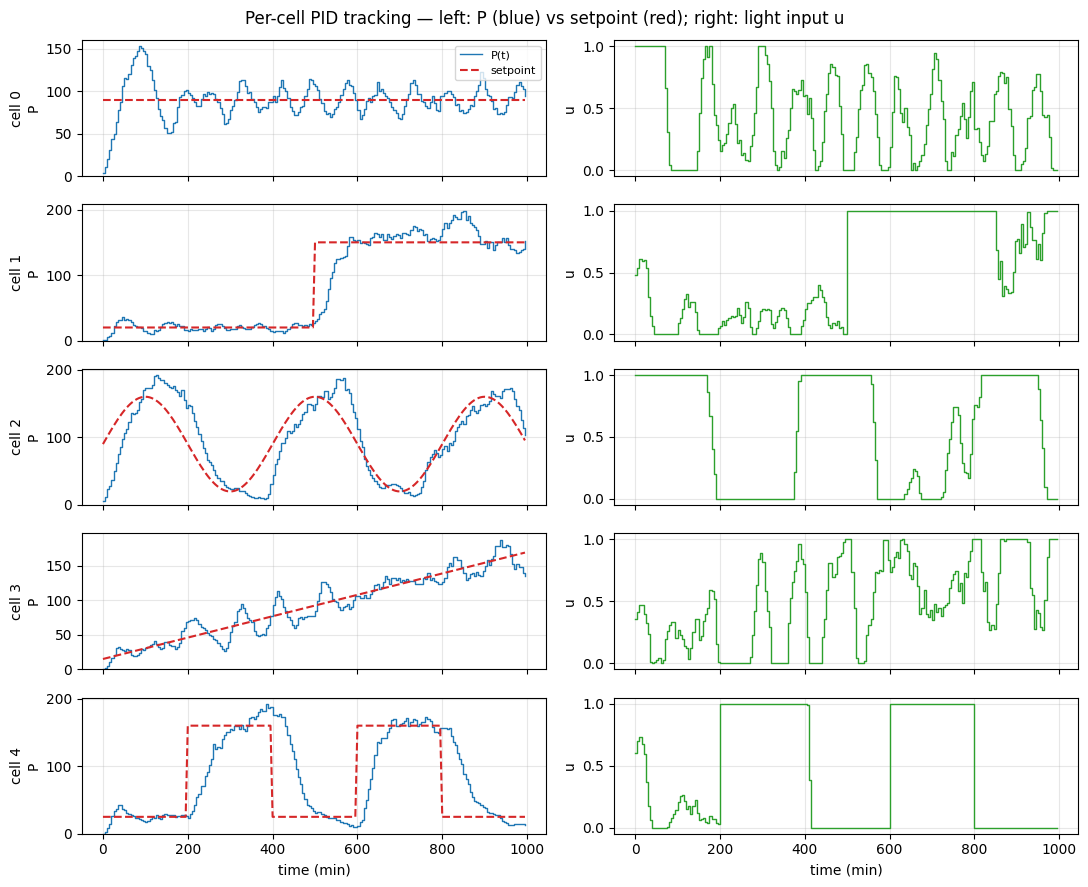

In [7]:
fig, axes = plt.subplots(N_CELLS, 2, figsize=(11, 1.8 * N_CELLS), sharex=True)
for i in range(N_CELLS):
    ax_p, ax_u = axes[i]
    # Left: P trajectory vs setpoint
    ax_p.step(times_np, xs[:, i, P_IDX], where="post", color="tab:blue", lw=1, label="P(t)")
    ax_p.plot(times_np, setpoints_np[:, i], color="tab:red", lw=1.5, ls="--", label="setpoint")
    ax_p.set_ylabel(f"cell {i}\nP")
    ax_p.set_ylim(bottom=0)
    ax_p.grid(alpha=0.3)
    if i == 0:
        ax_p.legend(loc="upper right", fontsize=8)
    # Right: control input u(t)
    ax_u.step(times_np, us[:, i], where="post", color="tab:green", lw=1)
    ax_u.set_ylabel("u")
    ax_u.set_ylim(-0.05, 1.05)
    ax_u.grid(alpha=0.3)

axes[-1, 0].set_xlabel("time (min)")
axes[-1, 1].set_xlabel("time (min)")
fig.suptitle("Per-cell PID tracking — left: P (blue) vs setpoint (red); right: light input u")
fig.tight_layout()
plt.show()

## What you should see

- **Cell 0 (constant 60)**: `u` settles to a steady value (~0.6) and `P` tracks 60 with stochastic noise.
- **Cell 1 (step)**: `u` saturates at 1 transiently as the controller pushes `P` up after the step; settles back into tracking.
- **Cell 2 (sine)**: `u` itself becomes a sinusoidal-ish curve, leading the setpoint slightly (predicting the plant's slow response). Note tracking error grows where the setpoint's derivative is large.
- **Cell 3 (ramp)**: `u` slowly increases; `P` lags slightly but tracks the ramp.
- **Cell 4 (square wave)**: `u` slams between low and high values at each setpoint switch; `P` shows the classic step-response shape with stochastic settling.

**Tracking errors**:

- The plant has fundamental bandwidth limits: protein half-life is 30 min, so `P` cannot track setpoint changes faster than ~10–20 min.
- Stochastic noise (σ ≈ √mean ≈ 8 around `P = 60`) is irreducible — the controller can't reject Poisson noise faster than the response time.
- The transfer curve saturates at `u = 1` (max `P ≈ 110`), so setpoints above ~110 are unreachable.

## Try yourself

- **Tune the gains**: `KP, KI, KD` — too high causes oscillation, too low causes slow tracking. Watch the square-wave cell for overshoot.
- **Faster control interval**: drop `DT` from 5 to 1 min and see if tracking improves.
- **Different setpoint shapes**: edit `setpoints_at` — exponential, chirp, random walk, etc.
- **More cells**: bump `N_CELLS` to 100 or 1000 — the `vmap` + `lax.scan` design parallelises with no Python overhead.
- **Heterogeneous controllers**: give each cell its own `KP, KI, KD` (vectorise the constants and pass them per-cell). Useful for cell-to-cell tuning or active-learning sweeps.